# Exploring TCKDB

**A guided tour of a live Thermochemical & Kinetics Database deployment.**

TCKDB stores computational-chemistry results — species, thermodynamics, kinetics,
and the quantum-chemistry calculations behind them — together with the provenance
needed to judge how much to trust each number.

This notebook queries a running deployment and reconstructs real thermodynamic
functions from it.

> **Read-only.** Every call here is an anonymous `GET`. Nothing in this notebook
> can modify the database. You do not need an account or an API key.

### The deployment this talks to

```
https://tckdb.homecalvin.com
```

That is Calvin's live TCKDB instance. The notebook points there by default, so you can
run it as-is — no signup, no key, no local database. Set `TCKDB_BASE_URL` if you want to
aim it somewhere else (your own local instance, say).

### What you need

Only `requests` and `matplotlib`. There *is* a proper Python client
(`pip install tckdb-client`) which is the better choice for programmatic work —
but it pins a contract version, so a client newer than the server it talks to will
fail on endpoints that server doesn't have yet. Plain HTTP keeps this tour working
against any deployment, which matters when you're handing it to someone else.

In [1]:
import math
import os

import requests

# Point this anywhere: a colleague's server, or your own localhost instance.
BASE_URL = os.environ.get("TCKDB_BASE_URL", "https://tckdb.homecalvin.com/api/v1").rstrip("/")
TIMEOUT_S = 30

# One connection, reused for every call below.
#
# Not a micro-optimisation. This host resolves to both A and AAAA records, and
# urllib3 tries resolved addresses *serially* -- so on a network where IPv6 is
# advertised but blackholed, every new connection waits for the IPv6 attempt to
# time out before falling back to IPv4. Measured from such a network: 18.4 s per
# call with a fresh connection, 144 ms with this session. curl does not show the
# problem because it races both stacks and abandons IPv6 in milliseconds.
SESSION = requests.Session()


def get(path, **params):
    """One anonymous GET, surfacing TCKDB's typed error envelope when present."""
    r = SESSION.get(f"{BASE_URL}/{path.lstrip('/')}", params=params, timeout=TIMEOUT_S)
    if not r.ok:
        try:
            e = r.json()
            raise RuntimeError(f"{r.status_code} {e.get('code','?')}: {e.get('detail', r.text[:200])}")
        except ValueError:
            r.raise_for_status()
    return r.json()


print("deployment:", BASE_URL)
print("health    :", get("health"))

deployment: https://tckdb.homecalvin.com/api/v1


health    : {'status': 'ok'}


## 1. Finding a species

The search endpoints are **lookup-by-identity**, not list-everything. You must supply
at least one of `smiles`, `inchi`, `inchi_key`, `formula`, `species_ref`, or
`species_entry_ref`.

That's deliberate for a scientific database: you ask for a molecule, not a page of rows.
Asking without an identifier returns a helpful `422` rather than dumping the table —
try it by deleting the `smiles=` argument below.

In [2]:
species = get("scientific/species/search", smiles="C=C")["records"]
print(f"matched {len(species)} species\n")

sp = species[0]
print("species_ref     :", sp["species_ref"])
print("canonical SMILES:", sp["canonical_smiles"])
print("InChIKey        :", sp["inchi_key"])
print("charge / mult   :", sp["charge"], "/", sp["multiplicity"])
print("entries         :", len(sp["entries"]))

# A "species" is the chemical identity; each "entry" is one physical
# interpretation of it (a minimum, a particular electronic state, ...).
for e in sp["entries"]:
    print(f"   {e['species_entry_ref']}  kind={e['species_entry_kind']}  "
          f"state={e['electronic_state_kind']}  review={e['review']['status']}")

SPECIES_REF = sp["species_ref"]
SPECIES_SMILES = sp["canonical_smiles"]

matched 1 species

species_ref     : spc_bzlnvjru7in32c2gz7peczhlwi
canonical SMILES: C=C
InChIKey        : VGGSQFUCUMXWEO-UHFFFAOYSA-N
charge / mult   : 0 / 1
entries         : 1
   spe_5nr24y2ssxokxlhsvymdwbpwmm  kind=minimum  state=ground  review=under_review


### Species vs. species *entry* — the distinction that matters

TCKDB separates **identity** from **interpretation**:

- a **species** is *what the molecule is* (deduplicated by InChIKey),
- a **species entry** is *one physical reading of it* — a particular minimum, a
  specific electronic state.

Thermo, kinetics and calculations attach to an **entry**, never to the bare identity.
So two conformers, or a ground and excited state, never silently blur into one number.

## 2. Thermodynamics

Each thermo record carries its model (`nasa`, `nasa9`, `wilhoit`), the standard-state
values, and its review status.

In [3]:
thermo = get("scientific/thermo/search", species_ref=SPECIES_REF)["records"]
print(f"{len(thermo)} thermo record(s) for {SPECIES_SMILES}\n")

for t in thermo:
    th = t["thermo"]
    h, s298 = th.get("h298_kj_mol"), th.get("s298_j_mol_k")
    print(f"  {th['thermo_ref']}  model={th['model_kind']:6s} origin={th['scientific_origin']:9s} "
          f"H298={h if h is None else round(h, 2)!s:>9s} kJ/mol   "
          f"S298={s298 if s298 is None else round(s298, 2)!s:>7s} J/mol/K   "
          f"[{th['review']['status']}]")

7 thermo record(s) for C=C

  thm_kehnhu3mmaxhm55xrjreryphhy  model=nasa   origin=computed  H298=    62.84 kJ/mol   S298=  218.8 J/mol/K   [under_review]
  thm_gk74mw4vyergttszkxgtjnyfwe  model=nasa   origin=computed  H298=    62.84 kJ/mol   S298=  218.8 J/mol/K   [under_review]
  thm_3xldk7zoo7fgqpfeydev2e4q5y  model=nasa   origin=computed  H298=    62.84 kJ/mol   S298=  218.8 J/mol/K   [under_review]
  thm_ry3rnspliwtmueeth7pitbinpy  model=nasa   origin=computed  H298=    62.84 kJ/mol   S298=  218.8 J/mol/K   [under_review]
  thm_nqtvuodj6trobe6rmv4ixtmxva  model=nasa   origin=computed  H298=    62.84 kJ/mol   S298=  218.8 J/mol/K   [under_review]
  thm_opilwohiutrg26h5xx6g5ib3r4  model=nasa   origin=computed  H298=    62.84 kJ/mol   S298=  218.8 J/mol/K   [under_review]
  thm_lzteqmvad6fzdz2cdejssxdlgu  model=nasa   origin=computed  H298=    62.84 kJ/mol   S298=  218.8 J/mol/K   [under_review]


### Reconstructing Cp(T), H(T), S(T)

A NASA-7 fit stores two coefficient sets meeting at `t_mid`. Evaluating them is what
turns a stored record back into thermodynamic functions — and it's the reason to query
thermo at all rather than just read a summary table.

$$\frac{C_p}{R} = a_1 + a_2T + a_3T^2 + a_4T^3 + a_5T^4$$
$$\frac{H}{RT} = a_1 + \frac{a_2T}{2} + \frac{a_3T^2}{3} + \frac{a_4T^3}{4} + \frac{a_5T^4}{5} + \frac{a_6}{T}$$
$$\frac{S}{R} = a_1\ln T + a_2T + \frac{a_3T^2}{2} + \frac{a_4T^3}{3} + \frac{a_5T^4}{4} + a_7$$

In [4]:
R = 8.31446261815324  # J/mol/K


def _coeffs(nasa, T):
    return nasa["low_temperature_coefficients"] if T <= nasa["t_mid"] else nasa["high_temperature_coefficients"]


def cp(nasa, T):
    a = _coeffs(nasa, T)
    return R * (a[0] + a[1]*T + a[2]*T**2 + a[3]*T**3 + a[4]*T**4)


def h(nasa, T):
    a = _coeffs(nasa, T)
    return R * T * (a[0] + a[1]*T/2 + a[2]*T**2/3 + a[3]*T**3/4 + a[4]*T**4/5 + a[5]/T) / 1000.0


def s(nasa, T):
    a = _coeffs(nasa, T)
    return R * (a[0]*math.log(T) + a[1]*T + a[2]*T**2/2 + a[3]*T**3/3 + a[4]*T**4/4 + a[6])


nasa = next(t["thermo"]["nasa"] for t in thermo if t["thermo"].get("nasa"))
print(f"valid {nasa['t_low']:.0f}-{nasa['t_high']:.0f} K, switching at {nasa['t_mid']:.1f} K")
print(f"\nCp(300 K) = {cp(nasa, 300):.2f} J/mol/K")
print(f"H (300 K) = {h(nasa, 300):.2f} kJ/mol")
print(f"S (300 K) = {s(nasa, 300):.2f} J/mol/K")

valid 10-3000 K, switching at 770.8 K

Cp(300 K) = 42.93 J/mol/K
H (300 K) = 62.92 kJ/mol
S (300 K) = 219.06 J/mol/K


### Sanity-checking against literature

Recomputed values are only worth anything if they agree with known ones. This is the
check to run before trusting anything else in the database.

In [5]:
REFERENCE = {  # NIST-JANAF / standard tables, 298-300 K
    "O":     {"name": "H2O",  "S298": 188.8, "Cp300": 33.6},
    "C=C":   {"name": "C2H4", "S298": 219.3, "Cp300": 43.6},
    "[CH3]": {"name": "CH3",  "S298": 194.2, "Cp300": 38.7},
    "[OH]":  {"name": "OH",   "S298": 183.7, "Cp300": 29.9},
}

print(f"{'species':8s} {'S298 db':>9s} {'S298 lit':>9s} {'Δ%':>7s}   {'Cp300 db':>9s} {'Cp300 lit':>10s} {'Δ%':>7s}")
print("-" * 68)
for smi, ref in REFERENCE.items():
    recs = get("scientific/species/search", smiles=smi)["records"]
    if not recs:
        print(f"{ref['name']:8s} not present in this deployment")
        continue
    ts = get("scientific/thermo/search", species_ref=recs[0]["species_ref"])["records"]
    n = next((t["thermo"]["nasa"] for t in ts if t["thermo"].get("nasa")), None)
    if n is None:
        print(f"{ref['name']:8s} no NASA polynomial stored")
        continue
    s_db, cp_db = s(n, 298.15), cp(n, 300)
    print(f"{ref['name']:8s} {s_db:9.2f} {ref['S298']:9.1f} {100*(s_db-ref['S298'])/ref['S298']:6.1f}%   "
          f"{cp_db:9.2f} {ref['Cp300']:10.1f} {100*(cp_db-ref['Cp300'])/ref['Cp300']:6.1f}%")

species    S298 db  S298 lit      Δ%    Cp300 db  Cp300 lit      Δ%
--------------------------------------------------------------------


H2O         188.66     188.8   -0.1%       33.59       33.6   -0.0%


C2H4        218.80     219.3   -0.2%       42.93       43.6   -1.5%


CH3         194.40     194.2    0.1%       38.93       38.7    0.6%


OH          178.19     183.7   -3.0%       29.10       29.9   -2.7%


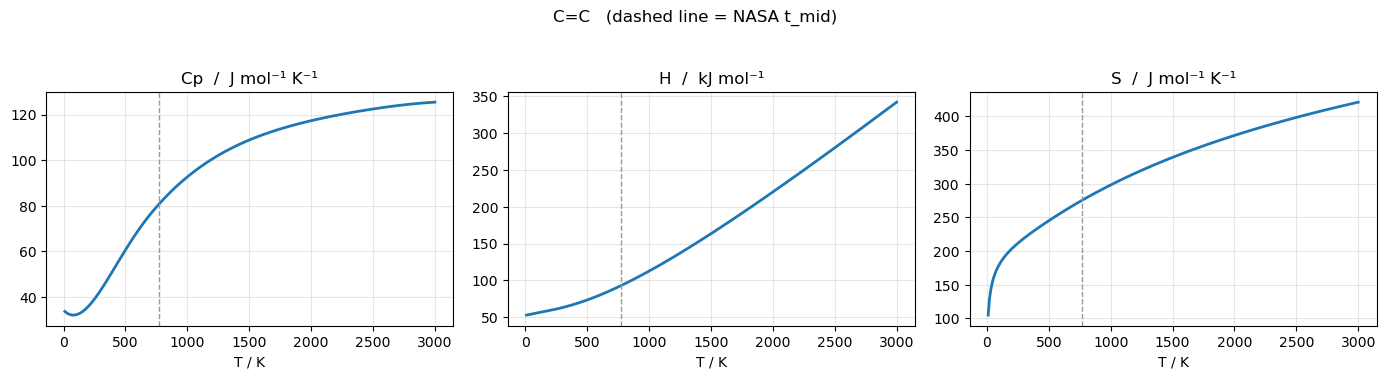

In [6]:
import matplotlib.pyplot as plt

T = [t for t in range(int(nasa["t_low"]) or 200, int(nasa["t_high"]) + 1, 10) if t > 0]
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
for axis, fn, label in zip(ax, (cp, h, s), ("Cp  /  J mol⁻¹ K⁻¹", "H  /  kJ mol⁻¹", "S  /  J mol⁻¹ K⁻¹")):
    axis.plot(T, [fn(nasa, t) for t in T], lw=2)
    axis.axvline(nasa["t_mid"], ls="--", c="0.6", lw=1)
    axis.set_xlabel("T / K")
    axis.set_title(label)
    axis.grid(alpha=0.3)
fig.suptitle(f"{SPECIES_SMILES}   (dashed line = NASA t_mid)", y=1.04)
plt.tight_layout()
plt.show()

## 3. The calculations behind the numbers

This is what distinguishes TCKDB from a table of values: every thermo record traces
back to the quantum-chemistry calculations that produced it, each with its level of
theory and software provenance.

In [7]:
calcs = get("scientific/calculations/search", species_ref=SPECIES_REF)["records"]
print(f"{len(calcs)} calculation(s) for {SPECIES_SMILES}\n")

# level_of_theory and software_release sit alongside `calculation` on the record,
# not inside it -- provenance is a peer of the result, not a detail of it.
by_type, by_lot = {}, {}
for rec in calcs:
    cal, lot = rec["calculation"], (rec.get("level_of_theory") or {})
    by_type[cal["type"]] = by_type.get(cal["type"], 0) + 1
    key = f"{lot.get('method','?')}/{lot.get('basis','?')}"
    by_lot[key] = by_lot.get(key, 0) + 1

print("by calculation type:", by_type)
print("by level of theory :", by_lot, "\n")

for rec in calcs[:6]:
    cal, lot = rec["calculation"], (rec.get("level_of_theory") or {})
    sw = (rec.get("software_release") or {})
    print(f"  {cal['calculation_ref']}  {cal['type']:5s} {cal['quality']:4s} "
          f"{lot.get('method','?')}/{lot.get('basis','?'):10s} {sw.get('software','?')} {sw.get('version','')}")

32 calculation(s) for C=C

by calculation type: {'sp': 7, 'freq': 7, 'opt': 18}
by level of theory : {'b3lyp/def2tzvp': 32} 

  calc_c3pgshx34sw7uaqfimxe2qeo6e  sp    raw  b3lyp/def2tzvp   Gaussian Gaussian 16, Revision C.02
  calc_uzdtyaspttrufuapeljaibbf54  freq  raw  b3lyp/def2tzvp   Gaussian Gaussian 16, Revision C.02
  calc_mxhadodv3hsdead3rnmofh3xyi  opt   raw  b3lyp/def2tzvp   Gaussian Gaussian 16, Revision C.02
  calc_j4my2yvcqowtzfdaufvpoqu3z4  opt   raw  b3lyp/def2tzvp   Gaussian Gaussian 16, Revision C.02
  calc_u7j7kghz7wxdi7odncrfwml7im  opt   raw  b3lyp/def2tzvp   Gaussian Gaussian 16, Revision C.02
  calc_j2rgfjta4ycv3k3wamogup2t6u  sp    raw  b3lyp/def2tzvp   Gaussian Gaussian 16, Revision C.02


## 4. Statistical mechanics

Frequencies, rotors and symmetry — the inputs a partition function is built from.
These are what make a thermo value *recomputable* rather than merely *quoted*.

In [8]:
sm = get("scientific/statmech/search", species_ref=SPECIES_REF)["records"]
print(f"{len(sm)} statmech record(s)\n")

for rec in sm[:4]:
    b = rec["statmech"]
    print(f"  {b['statmech_ref']}")
    print(f"     treatment={b['statmech_treatment']}  point_group={b['point_group']}  "
          f"symmetry={b['external_symmetry']}  linear={b['is_linear']}  "
          f"optical_isomers={b['optical_isomers']}")
    rot = [b[f"rotational_constant_{x}_cm1"] for x in ("a", "b", "c")]
    if any(r is not None for r in rot):
        print(f"     rotational constants /cm-1: {rot}")
    if b.get("frequency_scale_factor_value") is not None:
        print(f"     frequency scale factor: {b['frequency_scale_factor_value']}")

7 statmech record(s)

  sm_ub3tbslev5twt7btwtzcgouckq
     treatment=rrho  point_group=D2h  symmetry=4  linear=False  optical_isomers=1
     frequency scale factor: 0.999
  sm_4hxeerk7n4oslcjt4ivgk3rdiq
     treatment=rrho  point_group=D2h  symmetry=4  linear=False  optical_isomers=1
     frequency scale factor: 0.999
  sm_df3deeaphwtqeaj5btfsesds7e
     treatment=rrho  point_group=D2h  symmetry=4  linear=False  optical_isomers=1
     frequency scale factor: 0.999
  sm_pq5k4zcwhhzpzv7i2anuvnocw4
     treatment=rrho  point_group=D2h  symmetry=4  linear=False  optical_isomers=1
     frequency scale factor: 0.999


## 5. Review status — how much should you trust this?

Every scientific record carries a review state. TCKDB deliberately keeps three
*separate* judgements rather than collapsing them into one score:

| | question it answers |
|---|---|
| **review** | has a human curator signed off? |
| **trust** | is the supporting evidence complete? |
| **reproducibility** | is enough deposited to audit or re-run it? |

They can legitimately disagree — a well-evidenced record may be unreviewed, and a
reviewed record may still lack the artifacts needed to reproduce it. Collapsing them
would hide exactly the distinction a reader needs.

In [9]:
# Every search response carries a review roll-up for free.
print("review summary:", get("scientific/thermo/search", species_ref=SPECIES_REF)["review_summary"])

# Heavier blocks are opt-in. Ask for an illegal token and the server tells you
# exactly which are legal for that endpoint -- a fast way to explore the API.
try:
    get("scientific/thermo/search", species_ref=SPECIES_REF, include="not_a_real_token")
except RuntimeError as exc:
    print("\n", exc)

review summary: {'approved': 0, 'under_review': 7, 'not_reviewed': 0, 'deprecated': 0, 'rejected': 0, 'total': 7}



 422 unknown_include_token: unknown_include_token: token(s) ['not_a_real_token'] not legal for /scientific/thermo/search. Legal tokens: ['artifacts', 'assessments', 'calculations', 'internal_ids', 'provenance', 'review', 'all']


### A worked trust block

`include=trust` on a calculation returns the deterministic evidence evaluation —
the rubric that ran, the checks it passed, and the label it concluded. This is the
part that lets a reader decide for themselves rather than taking a status word on
faith.

In [10]:
# A calculation from the real-data validation set.
CALC_REF = "calc_hh7v4go23xr6drhbb4f4ewuvbq"

trust = get(f"scientific/calculations/{CALC_REF}", include="trust")["record"]["trust"]
print("review status:", trust["review_status"])
print("trust status :", trust["trust_status"])

ev = trust["evidence"]
print(f"\nrubric: {ev['rubric']} v{ev['rubric_version']}  ->  {ev['label']}")
print("\npassed checks:")
for check in ev.get("passed_checks", []):
    print("   +", check)
for check in ev.get("missing_checks", []) or []:
    print("   -", check, "(missing)")

review status: under_review
trust status : well_supported

rubric: computed_calculation_v1 v1  ->  well_supported

passed checks:
   + calculation_has_owner
   + calculation_type_present
   + level_of_theory_present
   + software_release_present
   + workflow_tool_release_present
   + input_geometry_present
   + output_geometry_present
   + result_block_present
   + geometry_validation_present
   + artifacts_present
   + parameters_parsed
   - quality_recorded (missing)


## 6. Where to go next

- `scientific/transport/search` — Lennard-Jones parameters
- `scientific/kinetics/search` and `scientific/reactions/search` — rate coefficients
- `scientific/calculations/{ref}?include=all` — the full record for one calculation,
  including artifacts and geometries

Every search response carries a `pagination` block; pass `include=` to opt into heavier
sections. Anything omitted by default is omitted on purpose — the default response is
meant to stay small and predictable.

### Using the typed client instead

```python
pip install tckdb-client
```
```python
from tckdb_client import TCKDBClient
with TCKDBClient(base_url="https://tckdb.homecalvin.com") as c:
    print(c.health())
```
Match the client version to the deployment: a client built against a newer contract will
404 on endpoints an older server doesn't serve yet.

---
*Read-only tour. The script form of this notebook is `explore_tckdb.py` in the same
directory, runnable as `python examples/clients/explore_tckdb.py`.*